## **Phi_4 with free boundary conditions - STLSQ Trainer**

## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  

**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 3
(60000, 100)


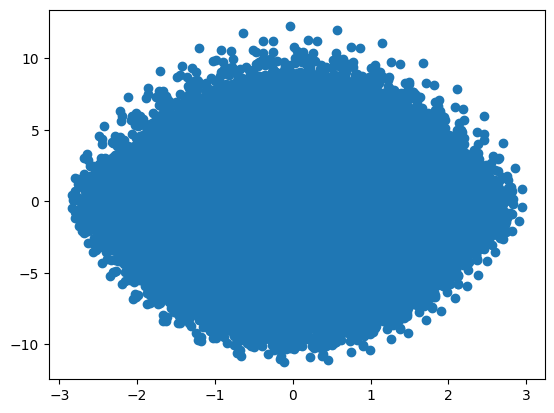

Training input shape: (60000, 100)
Training output shape: (60000, 100)


In [2]:
# Specify the model type
MY_MODEL = 'discrete_phi_quartic' 

SEED = 42  # set seed for random number generation
np.random.seed(SEED)


# Generate data based on the specified model type
node_num = 50 # number of nodes
C = 2.0 #coupling strength

#initial conditions for Simulation
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)

num_traj = 6
data_initial_conditions= []
for i in range(num_traj):

        x0 = np.random.normal(0, 0.1, size=xn.shape)  # random initial position
        d_x0 = np.random.normal(0, 0.1, size=xn.shape)  # random initial velocity

        new_IC = np.concatenate((x0, d_x0), axis=0) 
        data_initial_conditions.append(new_IC)

data_T =  500.0       # Length of the data (T)
data_dt = 0.05     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, random_state=SEED)

t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num, method='DOP853')

print("Guess highest order polynomial:", guess_highest_order_polynomial)

#plot x_train and dx_train
import matplotlib.pyplot as plt
print(x_train.shape)
plt.scatter(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**

In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 128
learning_rate = 0.01

### **1.4 Model Architecture Definitions**

**SREINet Parameters**

In [4]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[100, 100, 100]


## **II. Model and Training Preparation**

### **2.1 Create the SREINet Model**

In [5]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)

### **2.2 Loss Function**

In [6]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 Trainer**

In [8]:
from stlsq_trainer import *

trainer = STLSQTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**

#### **STLSQ Parameters**

In [9]:
# STLSQ training parameters
MAX_EPOCHS_PER_ITERATION = 80  # Maximum epochs per training iteration before pruning
MAX_ITERATIONS = 20  # Maximum number of prune-train iterations
PRUNING_THRESHOLD = 0.01  # Threshold for pruning weights
PLATEAU_WINDOW = 20  # Number of epochs to check for plateau
PLATEAU_THRESHOLD = 1e-6  # Threshold for relative loss change to be considered plateau
CONVERGENCE_THRESHOLD = 1e-10  # Threshold for convergence between iterations

### Training

In [10]:
# Setup
import time

training_histories = []
weights_list = []
loss_list = []

# Start timing
training_start_time = time.time()

In [11]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(
        training_input, 
        output,
        batch_size=MINI_BATCH_SIZE, 
        validation_split=0.20,
        max_epochs_per_iteration=MAX_EPOCHS_PER_ITERATION,
        max_iterations=MAX_ITERATIONS,
        pruning_threshold=PRUNING_THRESHOLD,
        plateau_window=PLATEAU_WINDOW,
        plateau_threshold=PLATEAU_THRESHOLD,
        convergence_threshold=CONVERGENCE_THRESHOLD,
        verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    # Reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

# End timing
training_end_time = time.time()
total_training_time = training_end_time - training_start_time

print(f"\n{'='*60}")
print(f"Total Training Time: {total_training_time:.2f} seconds ({total_training_time/60:.2f} minutes)")
print(f"{'='*60}")

Total Dimensions: 100
Training dimension 1...

STLSQ Iteration 1/20


  Iteration 1 complete: Min loss = 6.994451e-04
  Pruning: 20402 → 17462 nonzero weights (2940 pruned, 14.4% sparse)

STLSQ Iteration 2/20
  Iteration 2 complete: Min loss = 1.623054e-03
  Pruning: 20402 → 15647 nonzero weights (4755 pruned, 23.3% sparse)

STLSQ Iteration 3/20
  Iteration 3 complete: Min loss = 9.935187e-04
  Pruning: 17462 → 10893 nonzero weights (6569 pruned, 46.6% sparse)

STLSQ Iteration 4/20
  Iteration 4 complete: Min loss = 5.360351e-04
  Pruning: 15647 → 9267 nonzero weights (6380 pruned, 54.6% sparse)

STLSQ Iteration 5/20
  Iteration 5 complete: Min loss = 2.686401e-05
  Pruning: 10893 → 5956 nonzero weights (4937 pruned, 70.8% sparse)

STLSQ Iteration 6/20
  Iteration 6 complete: Min loss = 7.508654e-05
  Pruning: 9267 → 4494 nonzero weights (4773 pruned, 78.0% sparse)

STLSQ Iteration 7/20
  Iteration 7 complete: Min loss = 7.414079e-07
  Pruning: 5956 → 3418 nonzero weights (2538 pruned, 83.2% sparse)

STLSQ Iteration 8/20
  Iteration 8 complete: Min loss 

## **IV. Coefficient Reconstructor (SREINet)**

#### `generate_set_labels`

In [22]:
def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`

In [23]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results Display**
### **Identified Model**

In [26]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 1.000000007*x51
(x2)' = 1.000000002*x52
(x3)' = 1.000000012*x53
(x4)' = 0.9999999882*x54
(x5)' = 1.000000015*x55
(x6)' = 0.9999999932*x56
(x7)' = 1.000000001*x57
(x8)' = 0.9999999844*x58
(x9)' = 1.000000022*x59
(x10)' = 0.9999999748*x60
(x11)' = 1.000000097*x61
(x12)' = 0.9999999789*x62
(x13)' = 0.9999999971*x63
(x14)' = 0.9999999537*x64
(x15)' = 1.000000034*x65
(x16)' = 1.000000018*x66
(x17)' = 1.000000007*x67
(x18)' = 1.000000002*x68
(x19)' = 0.9999999988*x69
(x20)' = 0.9999999499*x70
(x21)' = 0.9999999839*x71
(x22)' = 0.999999951*x72
(x23)' = 0.9999998207*x73
(x24)' = 1.000000012*x74
(x25)' = 0.9999999469*x75
(x26)' = 1.000000049*x76
(x27)' = 1.000000047*x77
(x28)' = 0.9999999907*x78
(x29)' = 0.9999999372*x79
(x30)' = 0.9999999214*x80
(x31)' = 1.00000006*x81
(x32)' = 1.000000011*x82
(x33)' = 1.000000051*x83
(x34)' = 1.000000002*x84
(x35)' = 0.9999999767*x85
(x36)' = 1.000000039*x86
(x37)' = 1.000000042*x87
(x38)' = 1.000000052*x88
(x39)' = 1.00000005*x89
(x40)' = x90
(x41)' 

### **Validation**

In [27]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);

### Comparing vector field

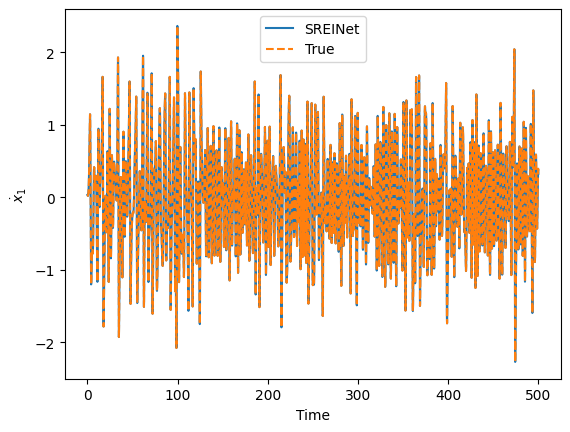

In [28]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()

### Comparing response

In [29]:
val_t_span = [0,100]
val_t_eval = np.arange(0,100,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

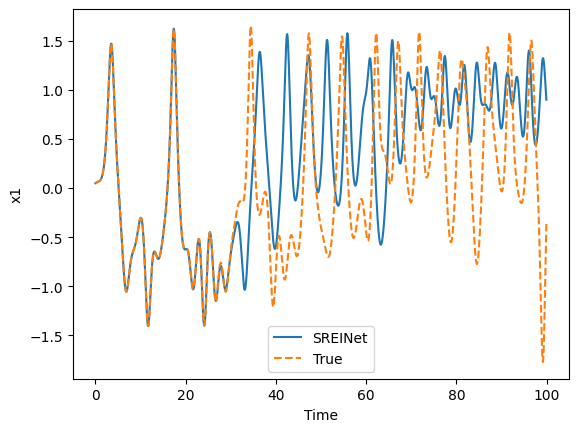

In [30]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()

In [31]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")

complexity_per_dimension = complexity // dim
print(f"complexity per dimension: {complexity_per_dimension}")

Score: 0.9999999661741242
Complexity: 252
complexity per dimension: 2


## **VI. Output**

In [20]:
# Save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'Trainer': ['STLSQ'],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Max Epochs Per Iteration': [MAX_EPOCHS_PER_ITERATION],
    'Max Iterations': [MAX_ITERATIONS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'pruning threshold': [PRUNING_THRESHOLD],
    'plateau window': [PLATEAU_WINDOW],
    'plateau threshold': [PLATEAU_THRESHOLD],
    'convergence threshold': [CONVERGENCE_THRESHOLD],
    'Total Training Time (seconds)': [total_training_time],
    'Total Training Time (minutes)': [total_training_time/60],
})

In [21]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='Phi4_stlsq_nn_configurations.xlsx',
    output_dir='output'
)

Successfully saved SREINet results to: output/Phi4_stlsq_nn_configurations.xlsx
